In [1]:
from amocatlas import read
from amoc_analysis import data
import matplotlib.pyplot as plt
%load_ext autoreload

In [2]:
from amoc_analysis.spectra_filtering.data_io import fill_gaps

# Read dataset
ds = read.move()   # 16N (also: read.osnap(), read.move(),read.samba(), read.fw2015(), ...)
# ds = read.rapid()   # 16N (also: read.osnap(), read.move(),read.samba(), read.fw2015(), ...)

# Fill data gaps (NaN)
moc_filled = fill_gaps(values=ds.MOC, method='linear')

dt_days = 2.0   # 48 h = 2 days
# dt_days = 0.5   # 48 h = 2 days

# ds.MOC

Loading 1 MOVE 16°N dataset(s):
  0. OS_MOVE_20000206-20221014_DPR_VOLUMETRANSPORT.nc: MOVE transport time series



In [3]:
from scipy.signal import butter, filtfilt
from amoc_analysis.spectra_filtering.filters import nyquist_frequency

def low_pass_filter_design(dt_days, f_cut_cpd, order=5):
    """Get Butterworth filter coefficients for zero-phase filtering."""
    # nyq = 0.5 / dt_days  # Nyquist frequency in cycles/day
    nyq = nyquist_frequency(dt_days)

    normalized_cutoff = f_cut_cpd / nyq  # Must be 0 < w < 1
    
    b, a = butter(order, normalized_cutoff, btype='low', analog=False)
    return b, a

In [4]:
%autoreload
from amoc_analysis.spectra_filtering.filters import butterworth_squared_response
from amoc_analysis.spectra_filtering.spectra import frequency_axis

freq = frequency_axis(n=len(moc_filled), dt_days=dt_days)

# moc_filtered = butterworth_squared_response(freq=freq, f_cut=0.1)
# moc_filtered = butterworth_squared_response(freq=moc_filled, f_cut=0.1)

b, a = low_pass_filter_design(dt_days=dt_days, f_cut_cpd=0.1)
moc_filtered = filtfilt(b, a, moc_filled)

# plt.loglog(freq, moc_filtered)

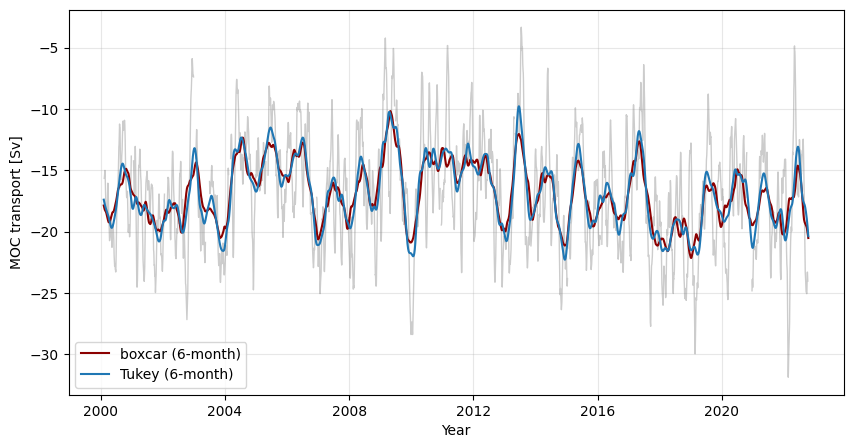

In [5]:
# Tukey filter
import pandas as pd
from amoc_analysis.spectra_filtering.filters import tukey_lowpass

window_size = round((365/12 * 6) / dt_days)

s = pd.Series(moc_filled)
box = s.rolling(window=window_size, center=True, win_type="boxcar", min_periods=1).mean()
tuk = tukey_lowpass(values=ds.MOC, window=window_size)
# moc_filtered = tuk

# Plot time series and boxcar vs Tukey
fig = plt.figure(figsize=(10,5))
plt.plot(ds.TIME, ds.MOC, lw=1, c='grey', alpha=0.4)
plt.plot(ds.TIME, box, c='darkred', label='boxcar (6-month)')
plt.plot(ds.TIME, tuk, c='tab:blue', label='Tukey (6-month)')

plt.xlabel('Year')
plt.ylabel('MOC transport [Sv]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Nyquist frequency f_N = 0.25 cycles per day (cpd)
Parseval ratio = 1.0099534998720099


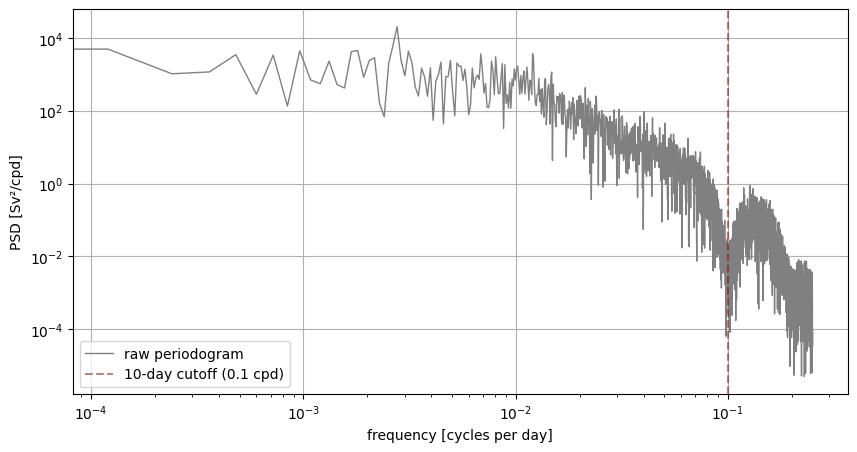

In [6]:
%autoreload
from amoc_analysis.spectra_filtering.spectra import raw_periodogram
from amoc_analysis.spectra_filtering.filters import nyquist_frequency

from scipy import signal

n = len(ds.MOC)
# dt_days = 2.0   # 48 h = 2 days

# Nyquist freq
# f_N = 1/(2*dt_days) # cycles per day (cpd)
f_N = nyquist_frequency(dt_days) # cycles per day (cpd)
print(f'Nyquist frequency f_N = {f_N} cycles per day (cpd)')


# Compute periodogram
# f, psd = raw_periodogram(x=moc_filled, dt_days=2.0, window='boxcar')
# f_period, psd_period = raw_periodogram(x=moc_filtered, dt_days=dt_days, window='tukey')
f_period, psd_period = raw_periodogram(x=moc_filled, dt_days=dt_days, window='tukey')
# f_period, psd_period = raw_periodogram(x=moc_filtered, dt_days=dt_days, window='boxcar')
# f_period, psd_period = raw_periodogram(x=moc_filled, dt_days=dt_days, window='boxcar')

fig = plt.figure(figsize=(10,5))

plt.loglog(f_period, psd_period, lw=1, c='grey', alpha=1, label='raw periodogram')
plt.axvline(x=0.1, c='darkred', ls='dashed', alpha=0.5, label='10-day cutoff (0.1 cpd)')

# Fig settings
# plt.ylim(bottom=1e-4)
# plt.xlim(left=1e-10)
plt.grid()
plt.legend()
plt.ylabel('PSD [Sv²/cpd]')
plt.xlabel('frequency [cycles per day]')

plt.show()

Nyquist frequency of 0.25 cpd means one full oscillation in 4 days

0.000244140625
Parseval ratio = 0.9947241688457643


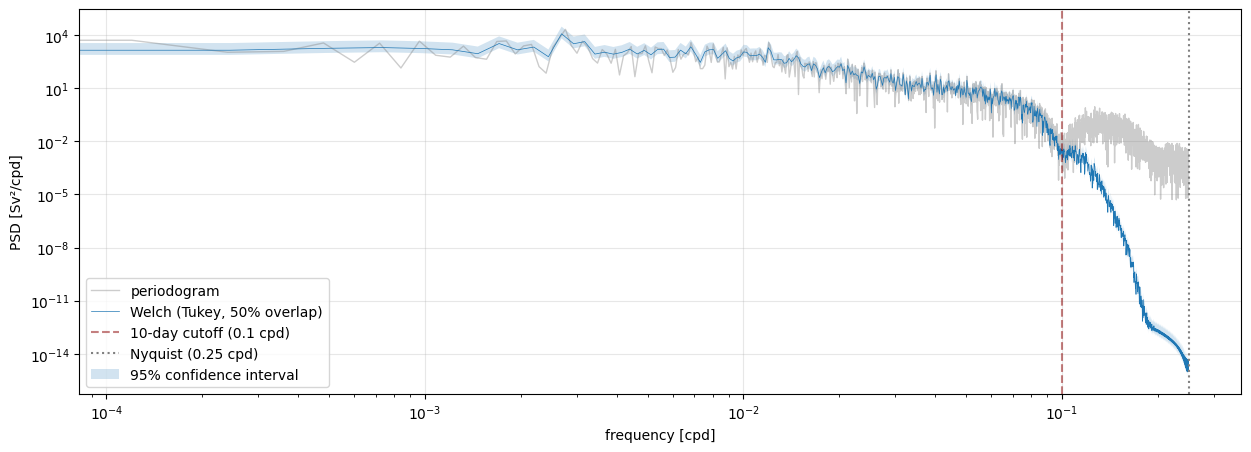

In [7]:
%autoreload
from amoc_analysis.spectra_filtering.spectra import welch_psd
from scipy.stats import chi2

segment_length=512
segment_length=1024
segment_length=2048
print(1 / (segment_length * dt_days))

# Compute Welch
# f_welch, psd_welch = welch_psd(x=moc_filled, dt_days=2.0, window='tukey', segment_length=segment_length)
f_welch, psd_welch = welch_psd(x=moc_filtered, dt_days=2.0, window='tukey', segment_length=segment_length, overlap=0.5)
# f_welch, psd_welch = welch_psd(x=moc_filled, dt_days=2.0, window='hann', segment_length=segment_length)

# Compute confidence intervals
# confidence band
K = 5; dof = 2 * K
# ~segments -> d.o.f.
lo = dof / chi2.ppf(0.95, dof)
hi = dof / chi2.ppf(0.05, dof)


# Plot results
fig = plt.figure(figsize=(15,5))

plt.loglog(f_period, psd_period, lw=1, c='grey', alpha=0.4, label='periodogram')
plt.loglog(f_welch, psd_welch, lw=0.5, c='tab:blue', alpha=1, label='Welch (Tukey, 50% overlap)')
plt.axvline(x=0.1, c='darkred', ls='dashed', alpha=0.5, label='10-day cutoff (0.1 cpd)')
plt.axvline(x=f_N, c='grey', ls='dotted', alpha=1, label='Nyquist (0.25 cpd)')

# PLot confidence interval around Welch
plt.fill_between(f_welch, psd_welch*lo, psd_welch*hi, alpha=0.2, label='95% confidence interval')

# Fig settings
# plt.ylim(bottom=1e-15)
# plt.xlim(left=1e-10)
plt.grid(alpha=0.3)
plt.legend()
plt.ylabel('PSD [Sv²/cpd]')
plt.xlabel('frequency [cpd]')

plt.show()

- use unfiltered data for periodogram with Tukey window
- use Butterworth-filtered data for Welch with Tukey window (50% overlap)